In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from google.colab import files

uploaded = files.upload()

Saving air_quality_historical.csv to air_quality_historical.csv


In [3]:
df = pd.read_csv("air_quality_historical.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()


Dataset loaded successfully!
Rows: 1298
Columns: 12


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
0,2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-08-04,55.236842,37.494737,724.526316,36.689474,13.668421,97.631579,1.059474,5.157895,1.078947,NaN,NaN
4,2022-08-05,59.895833,40.595833,625.791667,28.537500,15.375000,78.791667,0.965833,6.083333,1.095833,113.052632,72.631579


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1298 entries, 0 to 1297
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1298 non-null   object 
 1   pm10                   1295 non-null   float64
 2   pm2_5                  1295 non-null   float64
 3   carbon_monoxide        1295 non-null   float64
 4   nitrogen_dioxide       1295 non-null   float64
 5   sulphur_dioxide        1295 non-null   float64
 6   ozone                  1295 non-null   float64
 7   aerosol_optical_depth  1295 non-null   float64
 8   dust                   1295 non-null   float64
 9   uv_index               1295 non-null   float64
 10  us_aqi                 1294 non-null   float64
 11  european_aqi           1294 non-null   float64
dtypes: float64(11), object(1)
memory usage: 121.8+ KB
None


In [5]:
print(df.isnull().sum())

date                     0
pm10                     3
pm2_5                    3
carbon_monoxide          3
nitrogen_dioxide         3
sulphur_dioxide          3
ozone                    3
aerosol_optical_depth    3
dust                     3
uv_index                 3
us_aqi                   4
european_aqi             4
dtype: int64


In [6]:
df["date"] = pd.to_datetime(df["date"])

print(df.dtypes)

date                     datetime64[ns]
pm10                            float64
pm2_5                           float64
carbon_monoxide                 float64
nitrogen_dioxide                float64
sulphur_dioxide                 float64
ozone                           float64
aerosol_optical_depth           float64
dust                            float64
uv_index                        float64
us_aqi                          float64
european_aqi                    float64
dtype: object


In [7]:
df = df.sort_values("date").reset_index(drop=True)

print(df.head())
print(df.tail())

        date       pm10      pm2_5  carbon_monoxide  nitrogen_dioxide  \
0 2022-08-01        NaN        NaN              NaN               NaN   
1 2022-08-02        NaN        NaN              NaN               NaN   
2 2022-08-03        NaN        NaN              NaN               NaN   
3 2022-08-04  55.236842  37.494737       724.526316         36.689474   
4 2022-08-05  59.895833  40.595833       625.791667         28.537500   

   sulphur_dioxide      ozone  aerosol_optical_depth      dust  uv_index  \
0              NaN        NaN                    NaN       NaN       NaN   
1              NaN        NaN                    NaN       NaN       NaN   
2              NaN        NaN                    NaN       NaN       NaN   
3        13.668421  97.631579               1.059474  5.157895  1.078947   
4        15.375000  78.791667               0.965833  6.083333  1.095833   

       us_aqi  european_aqi  
0         NaN           NaN  
1         NaN           NaN  
2         NaN 

In [8]:
numeric_columns = [
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "aerosol_optical_depth",
    "dust",
    "uv_index"
]

df[numeric_columns] = df[numeric_columns].interpolate()

print(df.isnull().sum())

date                     0
pm10                     3
pm2_5                    3
carbon_monoxide          3
nitrogen_dioxide         3
sulphur_dioxide          3
ozone                    3
aerosol_optical_depth    3
dust                     3
uv_index                 3
us_aqi                   4
european_aqi             4
dtype: int64


In [9]:
df = df.dropna(subset=["us_aqi", "european_aqi"])

print(df.shape)
print(df.isnull().sum())

(1294, 12)
date                     0
pm10                     0
pm2_5                    0
carbon_monoxide          0
nitrogen_dioxide         0
sulphur_dioxide          0
ozone                    0
aerosol_optical_depth    0
dust                     0
uv_index                 0
us_aqi                   0
european_aqi             0
dtype: int64


In [10]:
df.describe()

,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
count,1294,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000
mean,2024-05-12 12:00:00,106.940353,72.925902,1296.603201,44.902421,18.542494,86.123261,0.588422,33.452280,1.198488,151.127713,99.905820
min,2022-08-05 00:00:00,0.954167,0.662500,59.416667,0.000000,0.412500,27.375000,0.040000,0.000000,0.097917,13.875000,12.625000
25%,2023-06-24 06:00:00,64.027083,41.807292,626.927083,26.756250,11.346875,69.416667,0.353750,3.093750,0.675521,123.666667,74.583333
50%,2024-05-12 12:00:00,91.333333,57.745833,985.395833,39.362500,15.037500,83.354167,0.536458,10.041667,1.162500,152.687500,89.229167
75%,2025-03-31 18:00:00,135.206250,91.495833,1606.427083,56.575000,22.991667,101.541667,0.754687,28.781250,1.668750,170.083333,114.531250
max,2026-02-18 00:00:00,578.762500,279.725000,7634.875000,170.504167,62.587500,155.666667,2.270000,841.541667,2.731250,486.083333,276.541667
std,NaN,61.075067,44.353023,994.738917,25.037525,9.999708,22.207163,0.312898,70.025052,0.571855,39.585885,36.009406


In [11]:
print("Number of rows:", len(df))
print("Start date:", df["date"].min())
print("End date:", df["date"].max())

Number of rows: 1294
Start date: 2022-08-05 00:00:00
End date: 2026-02-18 00:00:00


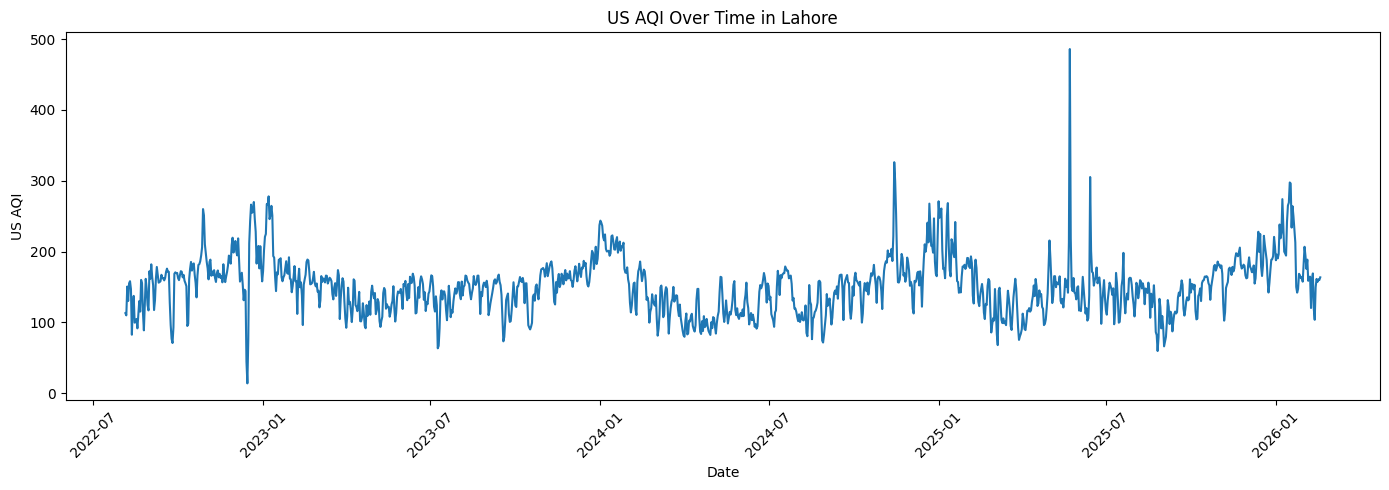

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(df["date"], df["us_aqi"])

plt.xlabel("Date")
plt.ylabel("US AQI")
plt.title("US AQI Over Time in Lahore")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
def simple_reflex_agent(aqi):

    if aqi <= 50:
        return "Good"

    elif aqi <= 100:
        return "Moderate"

    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"

    elif aqi <= 200:
        return "Unhealthy"

    elif aqi <= 300:
        return "Very Unhealthy"

    else:
        return "Hazardous"

In [14]:
df["AQI_Category"] = df["us_aqi"].apply(simple_reflex_agent)

print(df[["date", "us_aqi", "AQI_Category"]].head(20))

         date      us_aqi                    AQI_Category
4  2022-08-05  113.052632  Unhealthy for Sensitive Groups
5  2022-08-06  109.916667  Unhealthy for Sensitive Groups
6  2022-08-07  150.625000                       Unhealthy
7  2022-08-08  130.208333  Unhealthy for Sensitive Groups
8  2022-08-09  155.208333                       Unhealthy
9  2022-08-10  158.166667                       Unhealthy
10 2022-08-11  147.083333  Unhealthy for Sensitive Groups
11 2022-08-12   82.583333                        Moderate
12 2022-08-13  122.875000  Unhealthy for Sensitive Groups
13 2022-08-14  137.416667  Unhealthy for Sensitive Groups
14 2022-08-15   99.625000                        Moderate
15 2022-08-16  100.583333  Unhealthy for Sensitive Groups
16 2022-08-17  104.833333  Unhealthy for Sensitive Groups
17 2022-08-18   91.583333                        Moderate
18 2022-08-19  111.041667  Unhealthy for Sensitive Groups
19 2022-08-20  130.083333  Unhealthy for Sensitive Groups
20 2022-08-21 

In [15]:
test_values = [30, 75, 120, 180, 250, 350]

for value in test_values:
    print("AQI:", value, "->", simple_reflex_agent(value))

AQI: 30 -> Good
AQI: 75 -> Moderate
AQI: 120 -> Unhealthy for Sensitive Groups
AQI: 180 -> Unhealthy
AQI: 250 -> Very Unhealthy
AQI: 350 -> Hazardous


In [16]:
print(df["AQI_Category"].value_counts())

AQI_Category
Unhealthy                         582
Unhealthy for Sensitive Groups    495
Very Unhealthy                    111
Moderate                          101
Hazardous                           3
Good                                2
Name: count, dtype: int64


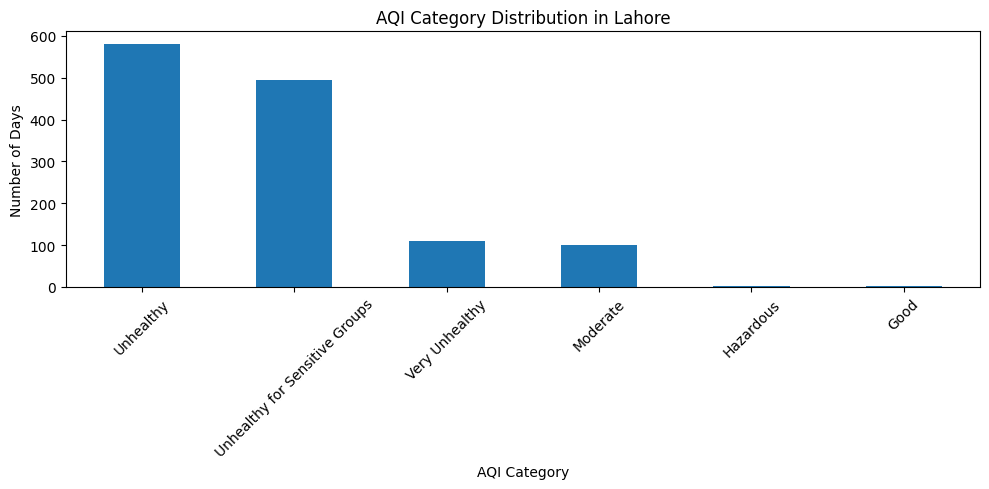

In [17]:
df["AQI_Category"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.xlabel("AQI Category")
plt.ylabel("Number of Days")
plt.title("AQI Category Distribution in Lahore")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features = [
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "aerosol_optical_depth",
    "dust",
    "uv_index"
]

X = df[features]
y = df["us_aqi"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 8.359794333807486
RMSE: 11.418863218383386
R² Score: 0.892789560193145


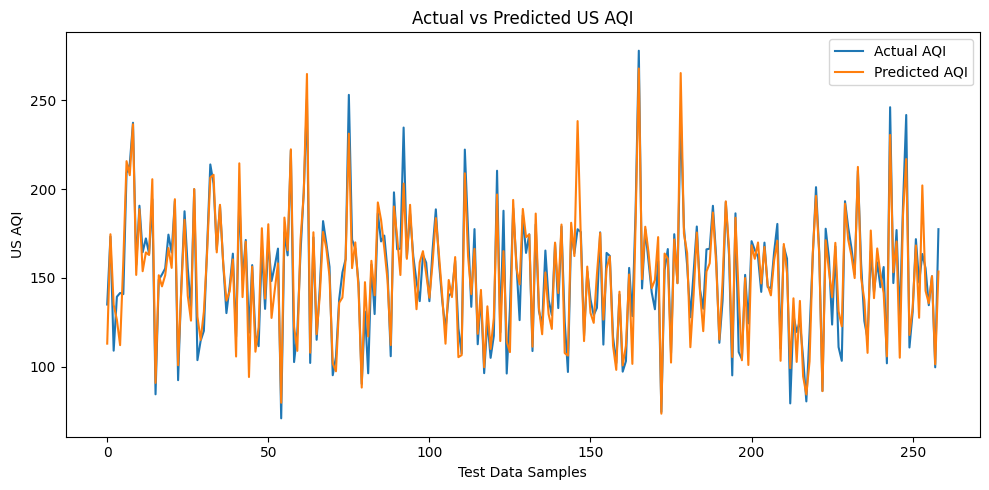

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(y_test.values, label="Actual AQI")
plt.plot(y_pred, label="Predicted AQI")

plt.xlabel("Test Data Samples")
plt.ylabel("US AQI")
plt.title("Actual vs Predicted US AQI")

plt.legend()
plt.tight_layout()
plt.show()

In [20]:
def simple_reflex_agent(aqi):

    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

In [21]:
for i in range(10):
    predicted_aqi = y_pred[i]
    category = simple_reflex_agent(predicted_aqi)

    print(
        "Predicted AQI:",
        round(predicted_aqi, 2),
        "->",
        category
    )

Predicted AQI: 112.97 -> Unhealthy for Sensitive Groups
Predicted AQI: 174.59 -> Unhealthy
Predicted AQI: 134.82 -> Unhealthy for Sensitive Groups
Predicted AQI: 126.39 -> Unhealthy for Sensitive Groups
Predicted AQI: 112.11 -> Unhealthy for Sensitive Groups
Predicted AQI: 159.53 -> Unhealthy
Predicted AQI: 215.77 -> Very Unhealthy
Predicted AQI: 207.87 -> Very Unhealthy
Predicted AQI: 236.56 -> Very Unhealthy
Predicted AQI: 151.68 -> Unhealthy


In [22]:
# Create data for next-day AQI prediction

forecast_df = df[["date", "us_aqi"]].copy()

# Previous AQI values
forecast_df["aqi_lag1"] = forecast_df["us_aqi"].shift(1)
forecast_df["aqi_lag2"] = forecast_df["us_aqi"].shift(2)
forecast_df["aqi_lag3"] = forecast_df["us_aqi"].shift(3)
forecast_df["aqi_lag7"] = forecast_df["us_aqi"].shift(7)

# Tomorrow's AQI as the target
forecast_df["tomorrow_aqi"] = forecast_df["us_aqi"].shift(-1)

forecast_df = forecast_df.dropna().reset_index(drop=True)

print(forecast_df.head())

        date      us_aqi    aqi_lag1    aqi_lag2    aqi_lag3    aqi_lag7  \
0 2022-08-12   82.583333  147.083333  158.166667  155.208333  113.052632   
1 2022-08-13  122.875000   82.583333  147.083333  158.166667  109.916667   
2 2022-08-14  137.416667  122.875000   82.583333  147.083333  150.625000   
3 2022-08-15   99.625000  137.416667  122.875000   82.583333  130.208333   
4 2022-08-16  100.583333   99.625000  137.416667  122.875000  155.208333   

   tomorrow_aqi  
0    122.875000  
1    137.416667  
2     99.625000  
3    100.583333  
4    104.833333  


In [23]:
from sklearn.ensemble import RandomForestRegressor

forecast_features = [
    "aqi_lag1",
    "aqi_lag2",
    "aqi_lag3",
    "aqi_lag7"
]

X_forecast = forecast_df[forecast_features]
y_forecast = forecast_df["tomorrow_aqi"]

# Keep the time order: first 80% for training
split = int(len(forecast_df) * 0.8)

X_train_f = X_forecast.iloc[:split]
X_test_f = X_forecast.iloc[split:]

y_train_f = y_forecast.iloc[:split]
y_test_f = y_forecast.iloc[split:]

forecast_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

forecast_model.fit(X_train_f, y_train_f)

print("Next-day AQI forecasting model trained successfully.")

Next-day AQI forecasting model trained successfully.


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

forecast_predictions = forecast_model.predict(X_test_f)

mae_f = mean_absolute_error(y_test_f, forecast_predictions)
rmse_f = np.sqrt(mean_squared_error(y_test_f, forecast_predictions))
r2_f = r2_score(y_test_f, forecast_predictions)

print("Next-Day Forecast Model")
print("MAE:", round(mae_f, 2))
print("RMSE:", round(rmse_f, 2))
print("R² Score:", round(r2_f, 3))

Next-Day Forecast Model
MAE: 23.89
RMSE: 32.09
R² Score: 0.357


In [25]:
# Get the latest AQI values

latest_aqi = df["us_aqi"].values

tomorrow_input = np.array([[
    latest_aqi[-1],   # latest AQI
    latest_aqi[-2],   # 2nd latest
    latest_aqi[-3],   # 3rd latest
    latest_aqi[-7]    # AQI 7 observations ago
]])

tomorrow_aqi = forecast_model.predict(tomorrow_input)[0]

print("Last recorded date:", df["date"].iloc[-1])
print("Predicted AQI for next day:", round(tomorrow_aqi, 2))

Last recorded date: 2026-02-18 00:00:00
Predicted AQI for next day: 141.86


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [26]:
tomorrow_category = simple_reflex_agent(tomorrow_aqi)

print("Predicted AQI:", round(tomorrow_aqi, 2))
print("Agent decision:", tomorrow_category)

Predicted AQI: 141.86
Agent decision: Unhealthy for Sensitive Groups
